In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)
nltk.download('stopwords')
print("All libraries imported successfully.")

Defaulting to user installation because normal site-packages is not writeable
All libraries imported successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load Fake and Real news CSVs
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Assign labels: 0 = Fake, 1 = Real
fake["label"] = 0
true["label"] = 1

# Combine and shuffle
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total articles: {len(data)}")
print(f"Fake articles : {len(fake)}")
print(f"Real articles : {len(true)}")
data.head()

Total articles: 44898
Fake articles : 23481
Real articles : 21417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


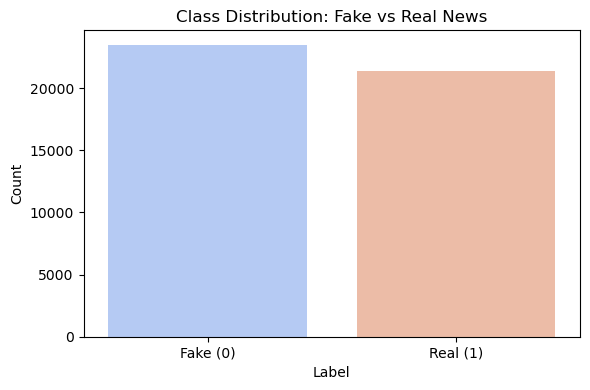

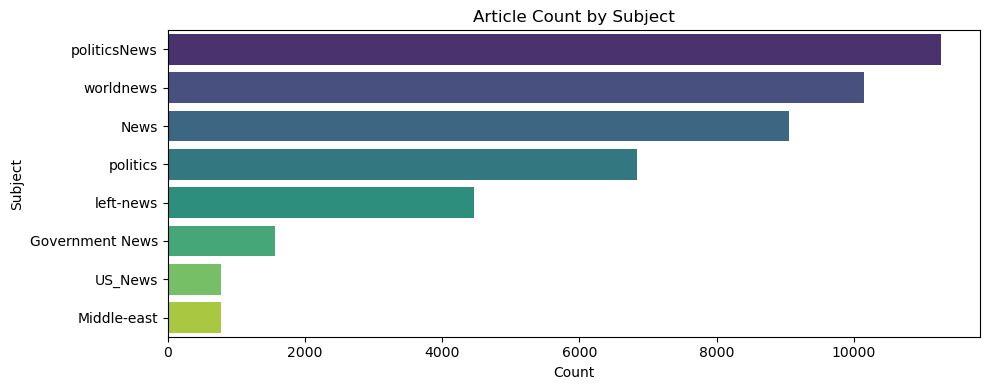

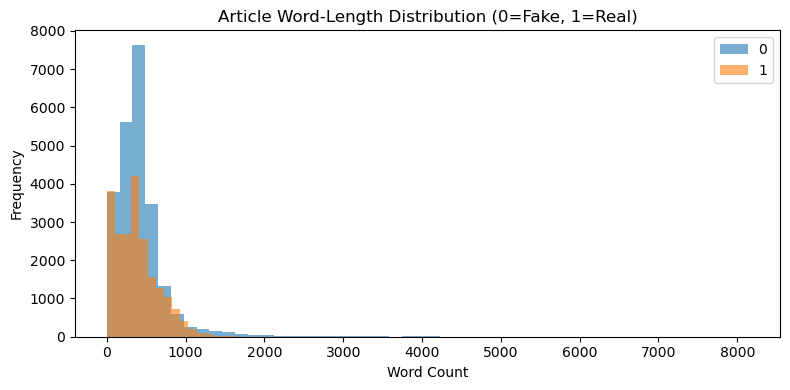


Average article length by label:
label
0    423.197905
1    385.640099
Name: text_length, dtype: float64


In [3]:
# 3a. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, palette='coolwarm')
plt.title("Class Distribution: Fake vs Real News")
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3b. Subject Distribution
plt.figure(figsize=(10, 4))
sns.countplot(y='subject', data=data, order=data['subject'].value_counts().index, palette='viridis')
plt.title("Article Count by Subject")
plt.xlabel("Count")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

# 3c. Article text length distribution
data['text_length'] = data['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
data.groupby('label')['text_length'].plot(kind='hist', bins=50, alpha=0.6, legend=True)
plt.title("Article Word-Length Distribution (0=Fake, 1=Real)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nAverage article length by label:")
print(data.groupby('label')['text_length'].mean())

In [4]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove non-alphabetic characters (tokenization)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Step 3: Split into words
    words = text.split()
    # Step 4: Remove stop words
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Combine title + text, then preprocess
data["content"] = data["title"] + " " + data["text"]
data["clean_text"] = data["content"].apply(preprocess_text)

print("Preprocessing complete.")
print("\nSample cleaned text:")
print(data["clean_text"].iloc[0][:300])

Preprocessing complete.

Sample cleaned text:
ben stein calls th circuit court committed coup tat constitution st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president tr
